# P2 · Superstore 数据探索分析（EDA）练习

**目标**：用 pandas 完成数据清洗 + 统计 + 5 张可视化，并写出 3-5 条业务发现。

**规则**：标 `【TODO】` 的格子需要你自己写代码完成，写完一个格子按 `Shift+Enter` 运行。
卡住超过 15 分钟可以问我，或看 `P2_参考答案.ipynb`（建议先自己做完再对答案）。

## 0. 导入库

In [1]:
# 运行本格，如果报错 ModuleNotFoundError，在命令行执行：
# pip install pandas matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 中文显示（Windows 用 SimHei；Mac 用 Arial Unicode MS；下面已都写上）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示

print('环境就绪，pandas 版本：', pd.__version__)

环境就绪，pandas 版本： 3.0.3


## 1. 加载数据

【知识点】`pd.read_csv()` 读入后是 DataFrame，`.head()` 看前 5 行，`.shape` 看行列数。

In [2]:
# 【TODO】读入 superstore.csv，命名为 df
# 提示：CSV 和 notebook 在同一目录时直接写文件名；不在同目录就写绝对路径
df = pd.read_csv('superstore.csv')

# 查看前 5 行
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-367753,11/02/2016,11/08/2016,Standard Class,XX-10136,Customer_137,Consumer,United States,Los Angeles,...,90001,West,PROD-OFF-0104,Office Supplies,Art,Art 2,3.82,1,0.7,-0.01
1,2,CA-2018-867710,09/16/2016,09/19/2016,Second Class,XX-10420,Customer_421,Corporate,United States,Baltimore,...,21201,East,PROD-OFF-0093,Office Supplies,Labels,Labels 3,19.56,3,0.4,6.49
2,3,CA-2018-413110,06/18/2018,06/25/2018,Standard Class,XX-10534,Customer_535,Home Office,United States,Raleigh,...,27601,South,PROD-OFF-0063,Office Supplies,Storage,Storage 3,69.90,1,0.6,-43.89
3,4,CA-2018-653640,07/17/2018,07/24/2018,Standard Class,XX-10219,Customer_220,Home Office,United States,Los Angeles,...,90001,West,PROD-FUR-0031,Furniture,Tables,Tables 1,428.21,1,0.2,-23.91
4,5,CA-2018-383831,10/09/2015,10/12/2015,First Class,XX-10372,Customer_373,Consumer,United States,New Orleans,...,70112,South,PROD-OFF-0051,Office Supplies,Supplies,Supplies 3,9.99,2,0.5,2.08


In [3]:
# 【TODO】打印数据的行数和列数（应该是 9994 行、21 列）
print(df.shape)

# 查看每列的非空数量和数据类型
df.info()

(9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity

## 2. 数据清洗

真实工作中这一步通常占 60% 时间。本数据较干净，重点做三件事：
1. 列名规范化（空格/连字符 → 下划线）
2. 日期列转 datetime
3. 派生分析字段：年、月、利润率

In [4]:
# 【TODO】把列名统一成小写、空格和连字符替换成下划线
df.columns = df.columns.str.lower().str.replace(' ','_').str.replace('-','_').tolist()
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [5]:
# 【TODO】检查缺失值：每列有多少个空值
df.isnull().sum()

# 【TODO】检查 row_id 是否有重复
print('重复行数：', df['row_id'].duplicated().sum())

重复行数： 0


In [6]:
# 【TODO】把 order_date 和 ship_date 转成日期类型
# 数据格式是 MM/DD/YYYY，用 format='%m/%d/%Y'
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y')
df['ship_date']  = pd.to_datetime(df['ship_date'],  format='%m/%d/%Y')

# 派生字段
df['year']      = df['order_date'].dt.year
df['month']     = df['order_date'].dt.month
df['weekday']   = df['order_date'].dt.day_name()
df['ship_days'] = (df['ship_date'] - df['order_date']).dt.days

df[['order_date','year','month','weekday','ship_days']].head()

,order_date,year,month,weekday,ship_days
0,2016-11-02,2016,11,Wednesday,6
1,2016-09-16,2016,9,Friday,3
2,2018-06-18,2018,6,Monday,7
3,2018-07-17,2018,7,Tuesday,7
4,2015-10-09,2015,10,Friday,3


In [7]:
# 【TODO】新增利润率列 = profit / sales
df['profit_margin'] = df['profit']/df['sales']
df[['sales','profit','profit_margin']].head()

,sales,profit,profit_margin
0,3.82,-0.01,-0.002618
1,19.56,6.49,0.331800
2,69.90,-43.89,-0.627897
3,428.21,-23.91,-0.055837
4,9.99,2.08,0.208208


## 3. 描述性统计

用数字回答：这家店盘子多大？赚不赚钱？谁在贡献、谁在拖后腿？

In [8]:
# 整体大盘 KPI
kpi = {
    '订单行数': len(df),
    '唯一订单数': df['order_id'].nunique(),
    '客户数': df['customer_id'].nunique(),
    '总销售额': round(df['sales'].sum(), 2),
    '总利润': round(df['profit'].sum(), 2),
    '整体利润率%': round(df['profit'].sum()/df['sales'].sum()*100, 2),
    '平均客单价': round(df['sales'].sum()/df['order_id'].nunique(), 2),
}
for k, v in kpi.items():
    print(f'{k}: {v:,}')

订单行数: 9,994
唯一订单数: 9,979
客户数: 800
总销售额: 4,104,081.28
总利润: 670,244.36
整体利润率%: 16.33
平均客单价: 411.27


In [9]:
# 【TODO】按 year 分组，统计每年的销售额、利润、利润率（%）
yearly = df.groupby('year').agg({'sales':'sum','profit':'sum'}).reset_index()
yearly['margin_pct'] = (yearly['profit']/yearly['sales']*100).round(2)
yearly

,year,sales,profit,margin_pct
0,2015,1056977.65,165772.22,15.68
1,2016,1019174.70,177412.93,17.41
2,2017,1023878.36,163830.53,16.00
3,2018,1004050.57,163228.68,16.26


In [10]:
# 【TODO】按 category 分组统计销售额、利润、利润率，并按利润升序排列
# 预期：你会看到 Furniture 利润为负
cat =  df.groupby('category').agg({'sales':'sum','profit':'sum'}).reset_index()
cat['profit_margin'] = (cat['profit']/cat['sales'].replace(0,1)*100).round(2)
cat = cat.sort_values('profit',ascending=True, ignore_index=True)
cat

,category,sales,profit,profit_margin
0,Furniture,996417.47,-34808.18,-3.49
1,Office Supplies,412580.16,55835.14,13.53
2,Technology,2695083.65,649217.40,24.09


In [11]:
# 【TODO】按 sub_category 分组，找出亏损 TOP3 和盈利 TOP3
sub = df.groupby('sub_category').agg(sales=('sales','sum'), profit=('profit','sum'))
sub['margin_pct'] = (sub['profit']/sub['sales'].replace(0,1)*100).round(2)
print('亏损 TOP3：')
print(sub.sort_values('profit').head(3))   
print('盈利 TOP3：')
print(sub.sort_values('profit').tail(3))

亏损 TOP3：
                  sales    profit  margin_pct
sub_category                                 
Tables        390788.90 -76129.51      -19.48
Bookcases     246817.08 -16924.25       -6.86
Storage        86087.07  -6963.67       -8.09
盈利 TOP3：
                   sales     profit  margin_pct
sub_category                                   
Machines       681325.82   95456.20       14.01
Phones         878601.26  178388.40       20.30
Copiers       1097342.80  366581.96       33.41


In [12]:
# 【TODO】折扣带分析：验证"高折扣=亏损"
df['discount_band'] = pd.cut(df['discount'],
                             bins=[-0.01, 0, 0.2, 0.4, 0.6, 1],
                             labels=['0%','1-20%','21-40%','41-60%','60%+'])
disc = df.groupby('discount_band', observed=True).agg(
    订单数=('sales','size'),
    销售额=('sales','sum'),
    利润=('profit','sum'))
disc['利润率%'] = (disc['利润']/disc['销售额']*100).round(2)
disc

,订单数,销售额,利润,利润率%
discount_band,,,,
0%,2915,1722296.76,376937.49,21.89
1-20%,2196,1062645.33,228315.48,21.49
21-40%,1527,646364.26,124719.21,19.30
41-60%,1517,436830.42,-31552.95,-7.22
60%+,1839,235944.51,-28174.87,-11.94


## 4. 可视化（5 张图）

每张图都要有：标题、轴标签、单位。画完问自己一句"这张图说明了什么？"


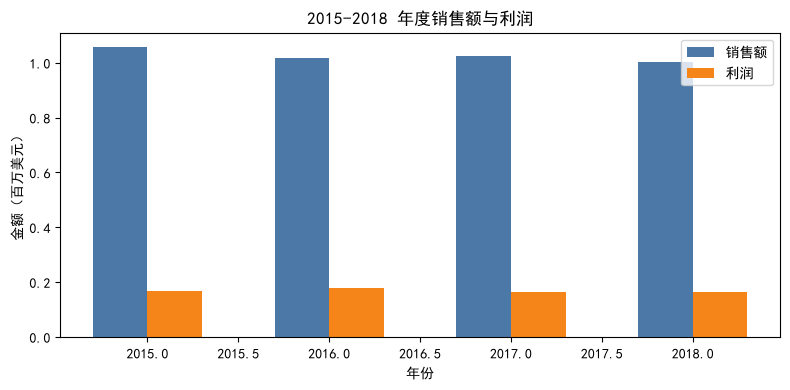

In [13]:
# 图1：年度销售额（柱）+ 利润（柱）双柱图
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.bar(yearly['year']-0.15, yearly['sales']/1e6, width=0.3, label='销售额', color='#4C78A8')
ax1.bar(yearly['year']+0.15, yearly['profit']/1e6, width=0.3, label='利润', color='#F58518')
ax1.set_xlabel('年份'); ax1.set_ylabel('金额（百万美元）')
ax1.set_title('2015-2018 年度销售额与利润')
ax1.legend()
plt.tight_layout(); plt.savefig('chart1_yearly.png', dpi=100);plt.show()

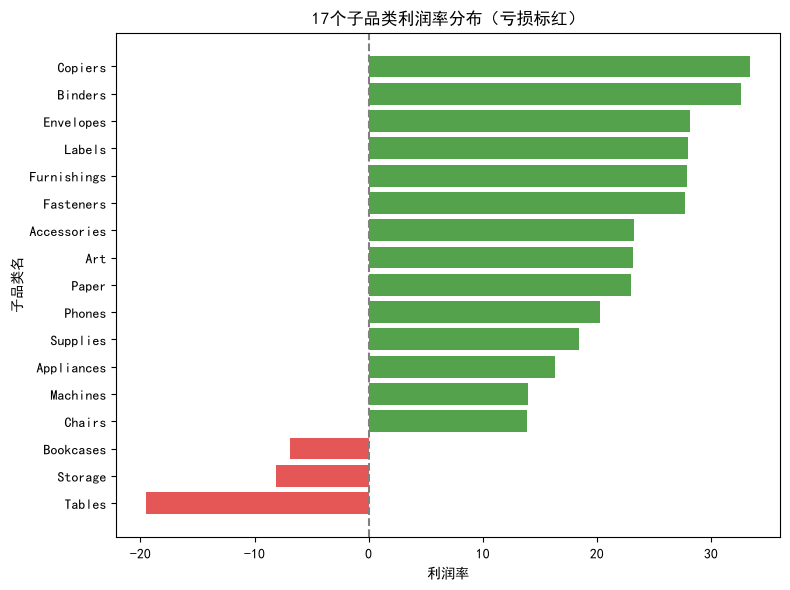

In [14]:
# 【TODO】图2：17 个子品类的利润率横向柱状图，亏损的标红
# 步骤提示：
# 1. sub 按 margin_pct 升序排序
# 2. colors = ['#E45756' if x < 0 else '#54A24B' for x in 排序后的margin]
# 3. plt.barh(子类名, 利润率, color=colors)
# 4. ax.axvline(0, color='gray') 画盈亏分界线
sub = sub.sort_values('margin_pct',ascending=True).reset_index()
colors = ['#E45756' if x < 0 else '#54A24B' for x in sub['margin_pct']]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(sub['sub_category'],sub['margin_pct'],color=colors)
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel('利润率')
ax.set_ylabel('子品类名')
ax.set_title('17个子品类利润率分布（亏损标红）')
plt.tight_layout()
plt.savefig('chart2_subcat.png', dpi=100);plt.show()

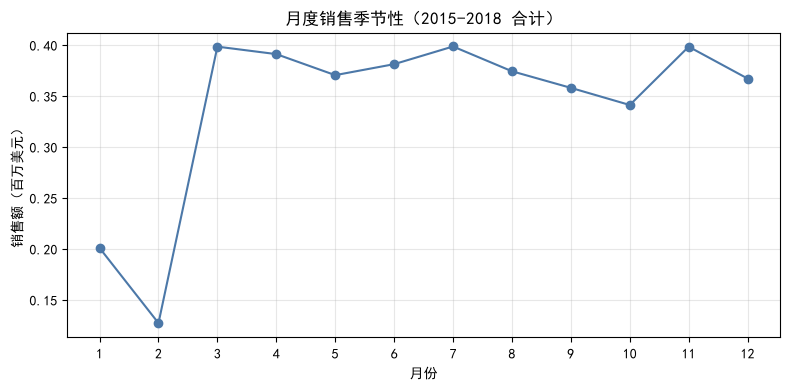

In [15]:
# 图3：月度季节性（四年各月销售额加总）
monthly = df.groupby('month')['sales'].sum()/1e6
plt.figure(figsize=(8,4))
plt.plot(monthly.index, monthly.values, marker='o', color='#4C78A8')
plt.xticks(range(1,13))
plt.xlabel('月份'); plt.ylabel('销售额（百万美元）')
plt.title('月度销售季节性（2015-2018 合计）')
plt.grid(alpha=0.3); plt.tight_layout();plt.savefig('chart3_monthly.png', dpi=100);plt.show()

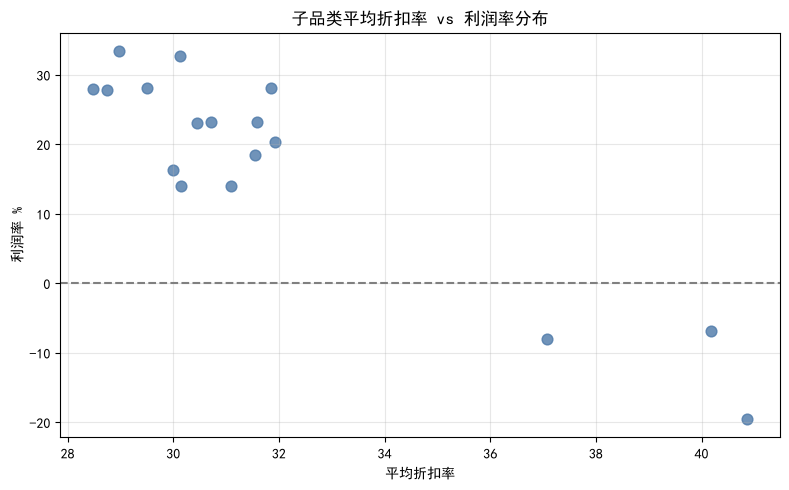

In [16]:
# 【TODO】图4：折扣率 vs 利润率散点图（用 17 个子品类层级画，不要用 9994 行）
# 先算每个子品类的平均折扣率，再和 sub['margin_pct'] 画散点
sub_discount = df.groupby('sub_category')['discount'].mean().reset_index()
sub_full = pd.merge(sub, sub_discount, on='sub_category')
plt.figure(figsize=(8,5))
plt.scatter(sub_full['discount']*100,sub_full['margin_pct'], color='#4C78A8', s=60, alpha=0.8)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('平均折扣率')
plt.ylabel('利润率 %')
plt.title('子品类平均折扣率 vs 利润率分布')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_discount.png', dpi=100);plt.show()

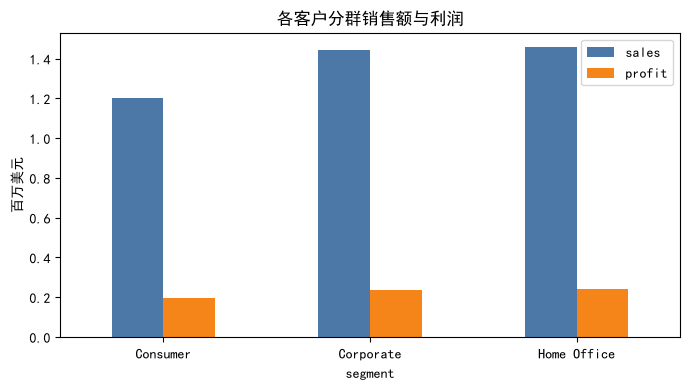

In [17]:
# 图5：各客户分群（segment）销售额与利润对比
seg = df.groupby('segment').agg(sales=('sales','sum'), profit=('profit','sum'))/1e6
seg.plot(kind='bar', figsize=(7,4), color=['#4C78A8','#F58518'])
plt.title('各客户分群销售额与利润'); plt.ylabel('百万美元')
plt.xticks(rotation=0); plt.tight_layout();plt.savefig('chart5_segment.png', dpi=100);plt.show()

## 5. 业务发现（用 Markdown 写下你的结论）

1.  **整体**：4 年 9979 单，销售 4.10M、利润0.67M，整体利润率 16.3%，年收入在1.0M上下波动、无增长趋势。

2.  **品类**：Furniture销售占24%却亏损$34.8K（-3%），根源是Tables（亏$76K，-20%）、Bookcases（-7%）、Storage（-8%）三个子品类；Technology以24%利润率贡献$649K利润，Copiers单品利润率33%是利润引擎。

3.  **折扣**：盈亏分水岭在40%折扣——≤40%折扣利润率19-22%，>40%转为亏损（41-60%档-7.2%，60%+档-11.9%）。Tables等高折扣商品正是亏损来源，两者互相印证。

4.  **季节性**：2月是全年谷底（$127K），3月反弹最强，7月/11月为小高峰；建议1月下旬启动促销备货，2月做清库存活动。

5.  **客户**：三类分群贡献接近（$1.20M-$1.46M），Home Office与Corporate略高，消费者运营不应偏科。

6.  **地区补充**：30个州全部盈利（最低Missouri $12.8K），本数据集的亏损是**品类/折扣问题而非地区问题**——分析结论要尊重数据，不能硬套"亏损地区"叙事。

**给 CEO 的 3 条建议**：
① 立即停止Tables/Bookcases超过40%的深度折扣，改为捆绑销售；
② 资源向Copiers/Phones等高利润品类倾斜；
③ 2月淡季做会员专享活动平滑收入波动。